Train accuracy: 0.9938
Validation accuracy: 0.9752


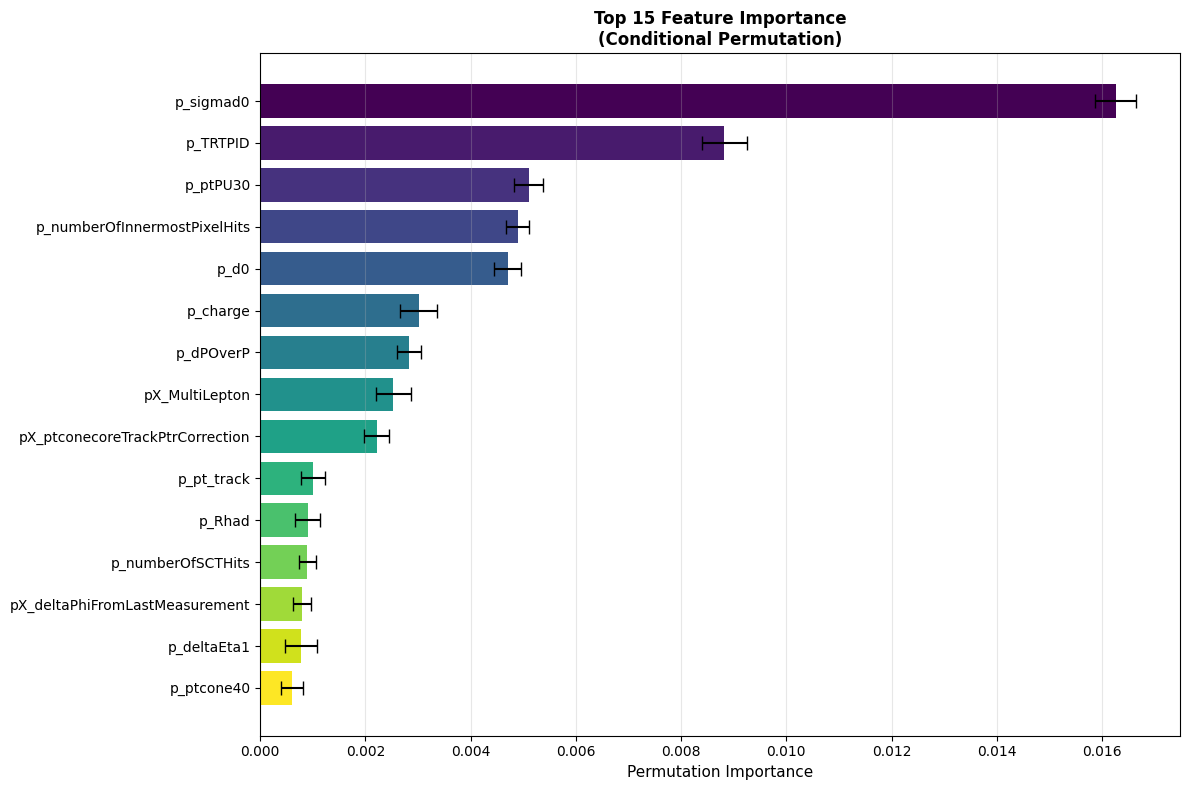

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier, XGBRegressor
from tqdm import tqdm

# Load data
class_train_data = pd.read_csv('../Data/AppML_InitialProject_train.csv')
class_test_data = pd.read_csv('../Data/AppML_InitialProject_test_classification.csv')

# Prepare features and target
target = class_train_data['p_Truth_isElectron']
variables = class_train_data.drop(columns=['p_Truth_isElectron', 'p_Truth_Energy'])

# Split into train/validation for calculating importance on unseen data
X_train, X_val, y_train, y_val = train_test_split(
    variables, target, test_size=0.2, random_state=42, stratify=target
)

# Train XGBoost model
model = XGBClassifier(
    n_estimators = 700,
    max_depth = 7,
    learning_rate = 0.04,
    subsample = 0.6,
    colsample_bytree = 0.85,
    gamma = 2.4,
    min_child_weight = 7,
    eval_metric = 'logloss',
    random_state = 42,
    n_jobs = -1
)

model.fit(X_train, y_train)

# Evaluate on validation set
train_score = model.score(X_train, y_train)
val_score = model.score(X_val, y_val)
print(f'Train accuracy: {train_score:.4f}')
print(f'Validation accuracy: {val_score:.4f}')

permutation_result = permutation_importance(
    model, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
importance_df = pd.DataFrame({
    'feature': X_val.columns,
    'importance': permutation_result.importances_mean,
    'std': permutation_result.importances_std
}).sort_values(by='importance', ascending=False)



# Bar plot
top_n = 15
top_features = importance_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], 
         xerr=top_features['std'], color=colors, capsize=5)
plt.xlabel('Permutation Importance', fontsize=11)
plt.title(f'Top {top_n} Feature Importance\n(Conditional Permutation)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()


In [3]:
# Retrain with top features
top_feature_names = top_features['feature'].tolist()
X_train_top = X_train[top_feature_names]
X_val_top = X_val[top_feature_names]

model_top = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model_top.fit(X_train_top, y_train)
train_score_top = model_top.score(X_train_top, y_train)
val_score_top = model_top.score(X_val_top, y_val)

print(f'Train accuracy with top features: {train_score_top:.4f}')
print(f'Validation accuracy with top features: {val_score_top:.4f}')

Train accuracy with top features: 0.9821
Validation accuracy with top features: 0.9712


In [5]:
# You may need to install this if you haven't: !pip install scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from xgboost import XGBClassifier

# Define the search space
# Note: Unlike Scipy's uniform(loc, scale), skopt uses (low, high)
search_space = {
    'n_estimators': Integer(2300, 3300),
    'max_depth': Integer(5, 20),
    'learning_rate': Real(0.025, 0.075, prior='log-uniform'), # Log-uniform is better for learning rates
    'subsample': Real(0.4, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'gamma': Real(1.5, 4.0),
    'min_child_weight': Integer(2, 20)
}

# Initialize BayesSearchCV
# n_iter=500 in Bayes is often more effective than n_iter=100 in Random Search
bayes_search = BayesSearchCV(
    estimator=XGBClassifier(
        eval_metric='logloss', 
        random_state=42, 
        n_jobs=-1,
        tree_method='hist' # Speeds up training significantly
    ),
    search_spaces=search_space,
    n_iter=100,       # Number of parameter settings sampled
    cv=5,            # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit on the reduced feature set (top 15)
# Assuming X_train_top and X_val_top were created from your CPI results
bayes_search.fit(X_train_top, y_train)

print(f'Best CV score: {bayes_search.best_score_:.4f}')
print(f'Best parameters: {bayes_search.best_params_}')

# Final evaluation
best_model = bayes_search.best_estimator_
val_score_tuned = best_model.score(X_val_top, y_val)
print(f'Validation accuracy after Bayesian tuning: {val_score_tuned:.4f}')

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [ ]:
"""
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Hyperparameter tuning for XGBoost on the reduced 15-feature set
param_distributions = {
    'n_estimators': randint(650, 1001),
    'max_depth': randint(5, 10),
    'learning_rate': uniform(0.025, 0.05),
    'subsample': uniform(0.45, 0.18),
    'colsample_bytree': uniform(0.85, 0.15),
    'gamma': uniform(1.5, 2.5),
    'min_child_weight': randint(2, 7)
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=100,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_top, y_train)

print(f'Best CV score: {random_search.best_score_:.4f}')
print(f'Best parameters: {random_search.best_params_}')

best_model = random_search.best_estimator_
val_score_tuned = best_model.score(X_val_top, y_val)
print(f'Validation accuracy after tuning: {val_score_tuned:.4f}')
"""

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best CV score: 0.9690
Best parameters: {'colsample_bytree': np.float64(0.8595267744385002), 'gamma': np.float64(1.5920546690899784), 'learning_rate': np.float64(0.03169260594003166), 'max_depth': 9, 'min_child_weight': 5, 'n_estimators': 846, 'subsample': np.float64(0.6299491811915034)}
Validation accuracy after tuning: 0.9679


In [19]:

# Final evaluation
best_model.fit(X_train_top, y_train)  # Ensure the best model is trained on the top features
best_model = bayes_search.best_estimator_
val_score_tuned = best_model.score(X_val_top, y_val)
print(f'Validation accuracy after Bayesian tuning: {val_score_tuned:.4f}')

Validation accuracy after Bayesian tuning: 0.9718


In [20]:
# Compute XGBoost parameter count (approx. number of leaf weights) and validation logloss
import numpy as np
from sklearn.metrics import log_loss

param_count = None
val_logloss = None

if 'best_model' in globals():
    try:
        booster = best_model.get_booster()
        trees = booster.get_dump(with_stats=False)
        leaf_count = 0
        for t in trees:
            for line in t.splitlines():
                # XGBoost tree dump lines containing 'leaf=' denote leaf nodes
                if 'leaf=' in line:
                    leaf_count += 1
        param_count = leaf_count  # each leaf has a weight parameter
    except Exception as e:
        print('Could not extract booster dump:', e)

# Validation log loss if X_val_top and y_val exist
if 'best_model' in globals() and 'X_val_top' in globals() and 'y_val' in globals():
    try:
        val_probs = best_model.predict_proba(X_val_top)
        val_logloss = float(log_loss(y_val, val_probs))
    except Exception as e:
        print('Could not compute validation log loss:', e)

print('Approx parameter count (leaf weights):', param_count)
print('Validation log loss (best_model on X_val_top):', val_logloss)

Approx parameter count (leaf weights): 18921
Validation log loss (best_model on X_val_top): 0.07646990831652209


In [15]:
# Diagnostic: XGBoost classifier — number of trees and average leaves per tree
booster = best_model.get_booster()
trees = booster.get_dump(with_stats=False)
n_trees = len(trees)
leaf_count = 0
for t in trees:
    for line in t.splitlines():
        if 'leaf=' in line:
            leaf_count += 1
print(f'n_trees: {n_trees}, total_leaves: {leaf_count}, avg_leaves_per_tree: {leaf_count / n_trees:.2f}')

n_trees: 3195, total_leaves: 21955, avg_leaves_per_tree: 6.87


In [14]:
# Print tuned best_model parameters (for key hyperparameters)
if 'best_model' in globals():
    params = best_model.get_params()
    keys = ['n_estimators','max_depth','learning_rate','subsample','colsample_bytree','gamma','min_child_weight']
    print('Best model hyperparameters:')
    for k in keys:
        print(f"{k}: {params.get(k)}")
else:
    print('best_model not available in notebook globals.')

Best model hyperparameters:
n_estimators: 3195
max_depth: 11
learning_rate: 0.054085611612491404
subsample: 0.601524371658356
colsample_bytree: 0.5652557234189701
gamma: 3.51736565314329
min_child_weight: 13


In [12]:
from pathlib import Path
#Train best model on full training data with top features
X_full_top = variables[top_feature_names]
best_model.fit(X_full_top, target)

# Load test data and extract top features
X_test = class_test_data[top_feature_names]

# Get probability predictions for class 1 (electron)
test_predictions = best_model.predict_proba(X_test)[:, 1]

# Define output paths and filenames
solution_name = "XGBoost"
name = "BenjaminSiddique"
output_dir = Path('../Classification/Output')
output_dir.mkdir(exist_ok=True)

# Export predictions
predictions_filename = f"Classification_{name}_{solution_name}.csv"
predictions_filepath = output_dir / predictions_filename
with open(predictions_filepath, 'w') as f:
    for idx, pred in enumerate(test_predictions):
        f.write(f"{idx},{pred:.6f}\n")

#Export chosen features
varlist_filename = f"Classification_{name}_{solution_name}_VariableList.csv"
varlist_filepath = output_dir / varlist_filename
with open(varlist_filepath, 'w') as f:
    for var in top_feature_names:
        f.write(f"{var}\n")